# Exercise 1

In [12]:
import locale
import math

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use French month labels if the locale is available, matching the lab template.
try:
    locale.setlocale(locale.LC_ALL, 'fr_FR.utf8')
except locale.Error:
    pass

# Data import: semicolon separator and comma decimal convention, as in the template.
data_path = 'edunao-files/Donnees_France_2024_fr_cet.csv'
france_2024_data = pd.read_csv(data_path, sep=';', decimal=',', index_col=0)
france_2024_data.index = pd.to_datetime(france_2024_data.index, utc=True).tz_convert('Europe/Paris')

load_mw = france_2024_data['Load'].astype(float)
load_gw = load_mw / 1000

# INSEE population at January 1, 2024: 66.380 million inhabitants in metropolitan France.
metropolitan_france_population = 66_380_000

# Standard time-axis style from the template.
Month = mdates.MonthLocator(bymonthday=1)
MonthFmt = mdates.DateFormatter('%b')

## 1.1 Question

How many values are there? Compare this with the number of hours in the year.

In [13]:
observed_values = len(load_mw)
expected_hours_2024 = 366 * 24  # 2024 is a leap year.

print(f'Observed hourly values: {observed_values}')
print(f'Expected hours in leap year 2024: {expected_hours_2024}')
print(f'Difference: {observed_values - expected_hours_2024}')

Observed hourly values: 8784
Expected hours in leap year 2024: 8784
Difference: 0


## 1.2 Question

Identify the values and occurrence dates of the maximum and minimum consumption levels. Comment on these dates.

In [14]:
max_time = load_mw.idxmax()
min_time = load_mw.idxmin()
max_load_mw = load_mw.loc[max_time]
min_load_mw = load_mw.loc[min_time]

print(f'Maximum load: {max_load_mw / 1000:.2f} GW at {max_time:%Y-%m-%d %H:%M %Z}')
print(f'Minimum load: {min_load_mw / 1000:.2f} GW at {min_time:%Y-%m-%d %H:%M %Z}')

print('\nComment:')
print('- The maximum occurs on a winter weekday around noon, consistent with high heating and daytime activity demand.')
print('- The minimum occurs early on a Sunday in spring, consistent with low activity and limited heating/cooling demand.')

Maximum load: 82.80 GW at 2024-01-10 12:00 CET
Minimum load: 29.57 GW at 2024-05-12 06:00 CEST

Comment:
- The maximum occurs on a winter weekday around noon, consistent with high heating and daytime activity demand.
- The minimum occurs early on a Sunday in spring, consistent with low activity and limited heating/cooling demand.


## 1.3 Question

Calculate the annual average value of consumed power. Normalize this value by the number of inhabitants in metropolitan France.

In [15]:
average_power_mw = load_mw.mean()
average_power_w_per_person = average_power_mw * 1_000_000 / metropolitan_france_population

print(f'Annual average consumed power: {average_power_mw / 1000:.2f} GW')
print(f'Per-capita average power: {average_power_w_per_person:.0f} W/person')

Annual average consumed power: 48.92 GW
Per-capita average power: 737 W/person


## 1.4 Question

Calculate the annual value of consumed electrical energy. Normalize this value by the number of inhabitants in metropolitan France.

In [16]:
# The data are hourly average powers in MW, so the hourly sum gives MWh.
annual_energy_mwh = load_mw.sum()
annual_energy_twh = annual_energy_mwh / 1_000_000
annual_energy_kwh_per_person = annual_energy_mwh * 1000 / metropolitan_france_population

print(f'Annual consumed electrical energy: {annual_energy_twh:.1f} TWh')
print(f'Per-capita annual consumed energy: {annual_energy_kwh_per_person:.0f} kWh/person/year')

Annual consumed electrical energy: 429.7 TWh
Per-capita annual consumed energy: 6473 kWh/person/year


## 1.5 Question

Plot the time evolution of consumed power. Visually identify three types of variation cycles, with their periods and amplitudes. What causes these variations?

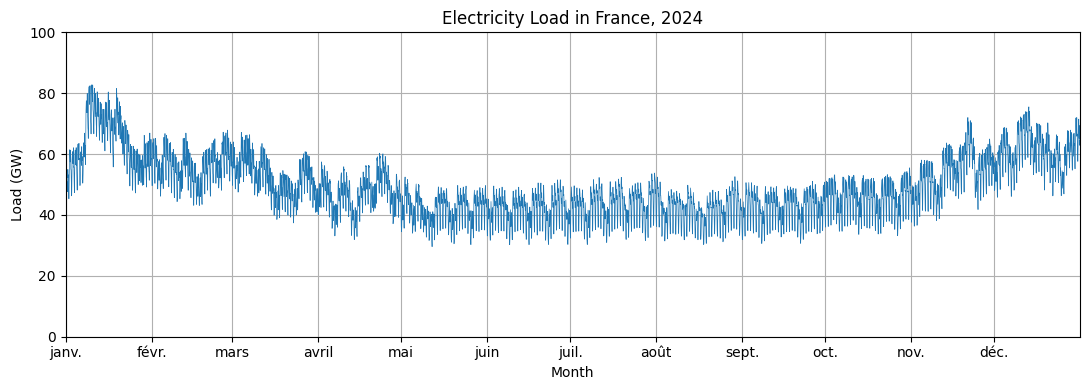

,Typical period,Estimated amplitude,Likely causes
Daily cycle,1 day,14.0 GW average daily max-min,"Day-night activity rhythm, business hours, coo..."
Weekly cycle,1 week,6.3 GW weekday-weekend average gap,Lower industrial and office activity during we...
Seasonal cycle,1 year,22.6 GW monthly-average max-min,"Seasonal heating demand, with winter much high..."


In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(load_gw.index, load_gw.values, linewidth=.5)
plt.title('Electricity Load in France, 2024')
ax.set_xlim(load_gw.index[0], load_gw.index[-1])
ax.xaxis.set_major_locator(Month)
ax.xaxis.set_major_formatter(MonthFmt)
plt.xlabel('Month')
ax.set_ylim(0, 100)
plt.ylabel('Load (GW)')
plt.grid(True)
fig.tight_layout()
fig.savefig('figures/exercise_1-5.pdf')
plt.show()

daily_amplitude_gw = (load_mw.resample('D').max() - load_mw.resample('D').min()) / 1000
monthly_average_gw = load_gw.resample('ME').mean()
weekday_average_gw = load_gw.groupby(load_gw.index.dayofweek).mean()

cycle_summary = pd.DataFrame(
    {
        'Typical period': ['1 day', '1 week', '1 year'],
        'Estimated amplitude': [
            f'{daily_amplitude_gw.mean():.1f} GW average daily max-min',
            f'{weekday_average_gw.max() - weekday_average_gw.min():.1f} GW weekday-weekend average gap',
            f'{monthly_average_gw.max() - monthly_average_gw.min():.1f} GW monthly-average max-min',
        ],
        'Likely causes': [
            'Day-night activity rhythm, business hours, cooking, lighting, and heating control.',
            'Lower industrial and office activity during weekends.',
            'Seasonal heating demand, with winter much higher than summer in France.',
        ],
    },
    index=['Daily cycle', 'Weekly cycle', 'Seasonal cycle'],
)
display(cycle_summary)

## 1.6 Question

Estimate the order of magnitude of the annual energy consumed for heating, in absolute value and as a proportion of total energy.

In [18]:
# Assumption: the non-heating baseline is the mean load over June, July, and August.
# Annual heating demand is approximated by summing only the positive hourly excess over that baseline.
non_heating_baseline_mw = load_mw[load_mw.index.month.isin([6, 7, 8])].mean()
heating_energy_twh = (load_mw - non_heating_baseline_mw).clip(lower=0).sum() / 1_000_000
heating_share = heating_energy_twh / annual_energy_twh

print(f'Non-heating baseline: {non_heating_baseline_mw / 1000:.1f} GW')
print(f'Annual heating-related electricity: about {heating_energy_twh:.1f} TWh')
print(f'Share of total electricity consumption: about {heating_share:.1%}')

Non-heating baseline: 41.8 GW
Annual heating-related electricity: about 72.0 TWh
Share of total electricity consumption: about 16.7%


## 1.7 Question

Plot consumed power in descending order of value. This type of curve is called a load duration curve. Comment on this curve.

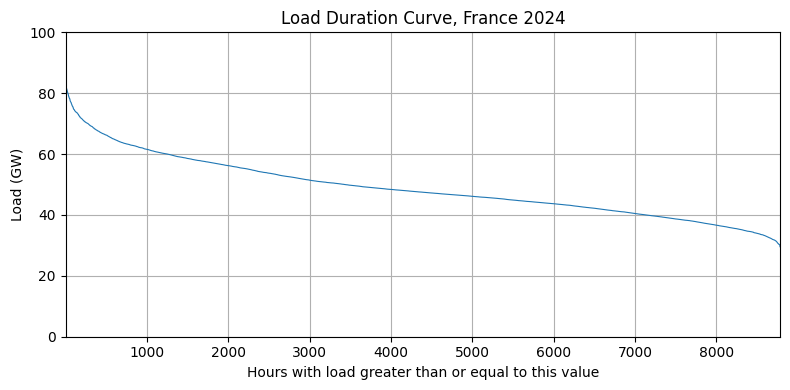

Comment:
- The left side shows rare peak-load hours, reaching about 83 GW.
- The flatter middle range represents the bulk of ordinary operating hours.
- The right side shows low-load hours near 30 GW, mostly nights, weekends, or mild-weather periods.


In [19]:
sorted_load_gw = load_gw.sort_values(ascending=False).reset_index(drop=True)
duration_hours = np.arange(1, len(sorted_load_gw) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(duration_hours, sorted_load_gw.values, linewidth=.8)
plt.title('Load Duration Curve, France 2024')
ax.set_xlim(1, len(sorted_load_gw))
plt.xlabel('Hours with load greater than or equal to this value')
ax.set_ylim(0, 100)
plt.ylabel('Load (GW)')
plt.grid(True)
fig.tight_layout()
fig.savefig('figures/exercise_1-7.pdf')
plt.show()

print('Comment:')
print('- The left side shows rare peak-load hours, reaching about 83 GW.')
print('- The flatter middle range represents the bulk of ordinary operating hours.')
print('- The right side shows low-load hours near 30 GW, mostly nights, weekends, or mild-weather periods.')

## 1.8 Question

Considering 40 million light vehicles in France, each driving an average of 11,700 km per year, calculate the electrical energy required to electrify the whole fleet. Use a consumption of 18 kWh/100 km.

In [20]:
vehicle_count = 40_000_000
distance_per_vehicle_km_per_year = 11_700
vehicle_consumption_kwh_per_100km = 18

ev_energy_kwh = vehicle_count * distance_per_vehicle_km_per_year * vehicle_consumption_kwh_per_100km / 100
ev_energy_twh = ev_energy_kwh / 1_000_000_000
ev_share_of_current_consumption = ev_energy_twh / annual_energy_twh

print(f'Annual electricity required: {ev_energy_twh:.1f} TWh')
print(f'Equivalent to about {ev_share_of_current_consumption:.1%} of 2024 electricity consumption.')

Annual electricity required: 84.2 TWh
Equivalent to about 19.6% of 2024 electricity consumption.
